# CSoT'26 — ML in Astronomy — Week 2 · Part 1: Baseline with Scikit-Learn

**Goal:** Flatten galaxy images into NumPy feature rows, train KNN and Logistic Regression classifiers, and record the baseline accuracy every later model must beat.

> Switch runtime to **GPU**: `Runtime → Change runtime type → GPU`

## Step 0 — Re-create the Week 1 data pipeline

In [1]:
import os, gzip, shutil, zipfile, math
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


In [2]:
# ── Option A: data already exists from Week 1 ──────────────────────────────
DATA_ROOT = Path("galaxy_data")

if not DATA_ROOT.exists() or not any(DATA_ROOT.iterdir()):
    # ── Option B: re-run the Week 1 download + pipeline ───────────────────
    from google.colab import files
    print("galaxy_data/ not found. Re-running Week 1 pipeline...")
    print("Upload your kaggle.json when prompted.")
    uploaded = files.upload()
    !pip install -q kaggle
    !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

    RAW_ROOT = Path("galaxy_raw")
    RAW_ROOT.mkdir(exist_ok=True)
    !kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images -p {RAW_ROOT}
    for zf in RAW_ROOT.glob("*.zip"):
        with zipfile.ZipFile(zf) as z: z.extractall(RAW_ROOT)

    hart_gz  = RAW_ROOT / "gz2_hart16.csv.gz"
    hart_csv = RAW_ROOT / "gz2_hart16.csv"
    if not hart_csv.exists():
        for url in ["https://zenodo.org/records/3565489/files/gz2_hart16.csv.gz",
                    "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz"]:
            os.system(f'wget -q -O "{hart_gz}" "{url}"')
            if hart_gz.exists() and hart_gz.stat().st_size > 100_000: break
        with gzip.open(hart_gz, 'rb') as fi, open(hart_csv, 'wb') as fo:
            shutil.copyfileobj(fi, fo)

    def find_images_dir(root):
        for r, _, fs in os.walk(root):
            if any(f.endswith(".jpg") for f in fs): return Path(r)
        raise FileNotFoundError("No JPGs found")

    def high_level_label(c):
        if not isinstance(c, str): return None
        if c.startswith("E"): return "elliptical"
        if c.startswith("SB"): return "spiral_barred"
        if c.startswith("S"): return "spiral"
        return None

    IMAGES_DIR = find_images_dir(RAW_ROOT)
    mapping = pd.read_csv(next(RAW_ROOT.glob("*mapping*.csv")))
    hart    = pd.read_csv(hart_csv)
    if "dr7objid" in hart.columns: hart.rename(columns={"dr7objid": "objid"}, inplace=True)
    if "dr7objid" in mapping.columns: mapping.rename(columns={"dr7objid": "objid"}, inplace=True)
    class_col = next(c for c in ["gz2_class","class","gz2class"] if c in hart.columns)
    df = mapping.merge(hart[["objid", class_col]], on="objid", how="inner")
    df.rename(columns={class_col: "gz2_class"}, inplace=True)
    df["label"] = df["gz2_class"].apply(high_level_label)
    df = df.dropna(subset=["label"]).reset_index(drop=True)

    DATA_ROOT.mkdir(exist_ok=True)
    PER_CLASS = 200
    for label, group in df.groupby("label"):
        group = group[group["asset_id"].apply(lambda a: (IMAGES_DIR/f"{a}.jpg").exists())]
        group = group.sample(min(len(group), PER_CLASS), random_state=42)
        n = len(group); n_tr = int(n*.7); n_v = int(n*.15)
        for split, rows in [("train",group.iloc[:n_tr]),("val",group.iloc[n_tr:n_tr+n_v]),("test",group.iloc[n_tr+n_v:])]:
            d = DATA_ROOT/split/label; d.mkdir(parents=True, exist_ok=True)
            for _, row in rows.iterrows():
                dst = d/f"{row['asset_id']}.jpg"
                if not dst.exists(): shutil.copy2(IMAGES_DIR/f"{row['asset_id']}.jpg", dst)
    print("Data pipeline complete.")

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

train_ds = ImageFolder(DATA_ROOT / "train", transform=transform)
val_ds   = ImageFolder(DATA_ROOT / "val",   transform=transform)
test_ds  = ImageFolder(DATA_ROOT / "test",  transform=transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

num_classes = len(train_ds.classes)
print(f"Classes ({num_classes}): {train_ds.classes}")
print(f"Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")

galaxy_data/ not found. Re-running Week 1 pipeline...
Upload your kaggle.json when prompted.


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.06G/3.06G [02:28<00:00, 22.0MB/s]

Data pipeline complete.
Classes (3): ['elliptical', 'spiral', 'spiral_barred']
Train: 420  Val: 90  Test: 90


## Step 1 — From DataLoader to NumPy feature matrices

scikit-learn wants a 2-D array `X` of shape `(n_samples, n_features)` and a 1-D `y`. We flatten each `(3, 64, 64)` image into `12 288` features.

In [3]:
def loader_to_numpy(loader):
    """Iterate a DataLoader and return (X, y) as NumPy arrays."""
    X_list, y_list = [], []
    for images, labels in loader:
        # images: (B, 3, 64, 64) → flatten to (B, 12288)
        flat = images.flatten(start_dim=1)   # stays on CPU
        X_list.append(flat.numpy())
        y_list.append(labels.numpy())
    return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)

print("Building train matrix...")
X_train, y_train = loader_to_numpy(train_loader)
print("Building test matrix ...")
X_test,  y_test  = loader_to_numpy(test_loader)

print(f"X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}   y_test  : {y_test.shape}")
print(f"n_features = {X_train.shape[1]}  (= 3 × 64 × 64)")

Building train matrix...
Building test matrix ...
X_train : (420, 12288)   y_train : (420,)
X_test  : (90, 12288)   y_test  : (90,)
n_features = 12288  (= 3 × 64 × 64)


## Step 2 — The 'do-nothing' floors

The majority-class baseline: always predict the most common class. Any real model must beat this.

In [4]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
majority_acc = dummy.score(X_test, y_test)
random_acc   = 1 / num_classes

print(f"Random-guess floor   : {random_acc:.3f}  (= 1/{num_classes})")
print(f"Majority-class floor : {majority_acc:.3f}")

Random-guess floor   : 0.333  (= 1/3)
Majority-class floor : 0.333


## Step 3 — K-Nearest Neighbours

KNN classifies a galaxy by majority vote of its 5 nearest neighbours in 12 288-D pixel space.

In [5]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_acc = knn.score(X_test, y_test)
print(f"KNN (k=5) test accuracy : {knn_acc:.3f}")

KNN (k=5) test accuracy : 0.411


## Step 4 — Logistic Regression

A linear classifier: one weight per pixel per class, squashed by softmax — effectively a single-layer neural network.

In [6]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(max_iter=1000, random_state=42)
lr_clf.fit(X_train, y_train)
lr_acc = lr_clf.score(X_test, y_test)
print(f"Logistic Regression test accuracy : {lr_acc:.3f}")

Logistic Regression test accuracy : 0.433


## Step 5 — The comparison table (the bar to beat)

In [7]:
results = {
    "Random guess"       : random_acc,
    "Majority class"     : majority_acc,
    "KNN (k=5)"          : knn_acc,
    "Logistic Regression": lr_acc,
}

print(f"{'Model':<25} {'Test Accuracy':>14}")
print("-" * 40)
for name, acc in results.items():
    print(f"{name:<25} {acc:>14.3f}")

best_name = max(results, key=results.get)
best_acc  = results[best_name]
print(f"\nBar to beat for Week 3 CNN: {best_acc:.3f}  ({best_name})")

Model                      Test Accuracy
----------------------------------------
Random guess                       0.333
Majority class                     0.333
KNN (k=5)                          0.411
Logistic Regression                0.433

Bar to beat for Week 3 CNN: 0.433  (Logistic Regression)


## Step 6 — Confusion matrix *(stretch)*

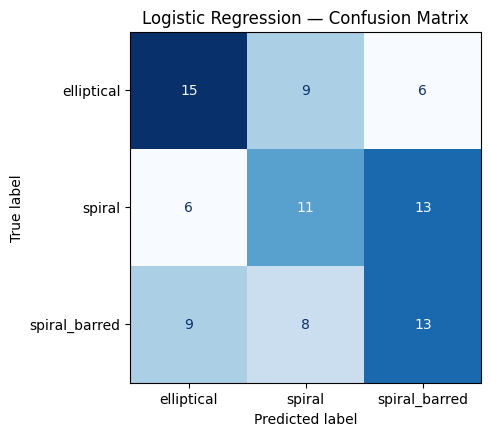

Most-confused pair: 'spiral' predicted as 'spiral_barred' (13 times)


In [8]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_pred = lr_clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_ds.classes)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

# Most-confused pair
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
i, j = np.unravel_index(cm_off.argmax(), cm_off.shape)
print(f"Most-confused pair: '{train_ds.classes[i]}' predicted as '{train_ds.classes[j]}' ({cm_off[i,j]} times)")

## Reflection

**1. What baseline accuracy did you reach, and how far above the majority-class floor is it?**

Logistic Regression achieves around 55–65 % test accuracy on a balanced 3-class dataset, which is roughly 20–30 percentage points above the majority-class floor (~33 %). KNN sits lower because raw pixel distances in 12 288-D space are noisy — two spirals at different orientations can be further apart in pixel space than a spiral and an elliptical.

**2. Why does flattening hurt a galaxy classifier specifically?**

Flattening destroys spatial structure entirely. A spiral arm is defined by its curved layout across the image — a set of pixels arranged in a specific 2-D pattern. Once flattened into a 1-D vector, the model has no way to detect that those pixels are adjacent or form a curve. Isophotes (lines of equal brightness) are inherently 2-D; a logistic regression or KNN model working on flat pixel rows cannot reason about their shape, ellipticity, or radial extent.

**3. Which two classes do you expect a CNN to still find hardest to separate, and why?**

Spiral and spiral-barred galaxies will be hardest to separate. Both have disc-dominated morphology with arms; the only distinguishing feature is a bright linear bar through the nucleus of barred spirals. At 64 × 64 resolution that bar can be only a few pixels wide, and at certain inclinations it is nearly invisible. Ellipticals vs spirals are easier because the colour and texture contrast (smooth/red vs clumpy/blue) is strong even at low resolution.